<a href="https://colab.research.google.com/github/Hoot-Vaughn/Stocks_Project/blob/main/Supervised_Learning_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
import pandas as pd
import os
import glob
import sys

def fetch_stock_data():
    """
    Downloading the 'World Stock Prices' and load it.
    """
    dataset_handle = "nelgiriyewithana/world-stock-prices-daily-updating"
    print(f"Downloading the dataset: {dataset_handle}")

    try:
        # Download the dataset.
        path = kagglehub.dataset_download(dataset_handle)
        print(f"Dataset successfully downloaded/cached at: {path}")

        search_pattern = os.path.join(path, "**", "*.csv")
        csv_files = glob.glob(search_pattern, recursive=True)

        if not csv_files:
            raise FileNotFoundError("No CSV files found in the downloaded dataset directory.")

        primary_file = max(csv_files, key=os.path.getsize)
        print(f"Identified primary data file: {os.path.basename(primary_file)}")
        print(f"Full file path: {primary_file}")

        # Load the data
        print("Loading the stocks data")
        df = pd.read_csv(primary_file)
        print(f"shape of the stocks data; Shape: {df.shape}")

        return df

    except Exception as e:
        print(f"CRITICAL ERROR during data extraction: {e}")
        return None

if __name__ == "__main__":
    # Execute the extraction
    stock_df = fetch_stock_data()

    if stock_df is not None:
        print("\nDataset Preview")
        print(stock_df.head())
        print("\nColumn Info")
        print(stock_df.info())
        print("\n Summary Statistics")
        print(stock_df.describe())

100%|██████████| 11.9M/11.9M [00:00<00:00, 46.8MB/s]

Extracting files...


Dataset successfully downloaded/cached at: /root/.cache/kagglehub/datasets/nelgiriyewithana/world-stock-prices-daily-updating/versions/400
Identified primary data file: World-Stock-Prices-Dataset.csv
Full file path: /root/.cache/kagglehub/datasets/nelgiriyewithana/world-stock-prices-daily-updating/versions/400/World-Stock-Prices-Dataset.csv
Loading the stocks data
shape of the stocks data; Shape: (310122, 13)

Dataset Preview
                        Date        Open        High         Low       Close  \
0  2025-07-03 00:00:00-04:00    6.630000    6.740000    6.615000    6.640000   
1  2025-07-03 00:00:00-04:00  106.750000  108.370003  106.330101  107.339996   
2  2025-07-03 00:00:00-04:00  122.629997  123.050003  121.550003  121.930000   
3  2025-07-03 00:00:00-04:00  221.705002  224.009995  221.360001  223.410004   
4  2025-07-03 00:00:00-04:00  212.145004  214.649994  211.810104  213.550003   

       Volume Brand_Name Ticker Industry_Tag  Country  Dividends  \
0   4209664.0    pelo

# **Exploratory Data Analysis Step**


stock analysis for apple stocks AAPL ---


/tmp/ipykernel_464/2181805622.py:19: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_ticker['Date'] = pd.to_datetime(df_ticker['Date'])


Check missing values:
Open                0
High                0
Low                 0
Close               0
Volume              0
Brand_Name          0
Ticker              0
Industry_Tag        0
Country             0
Dividends           0
Stock Splits        0
Capital Gains    6470
dtype: int64


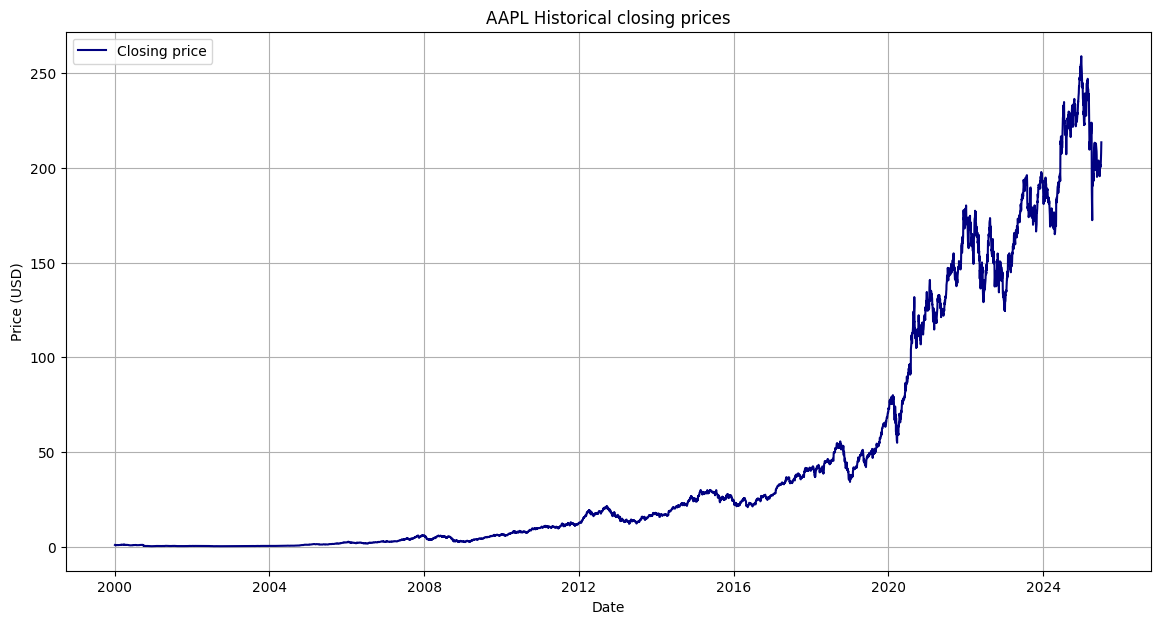

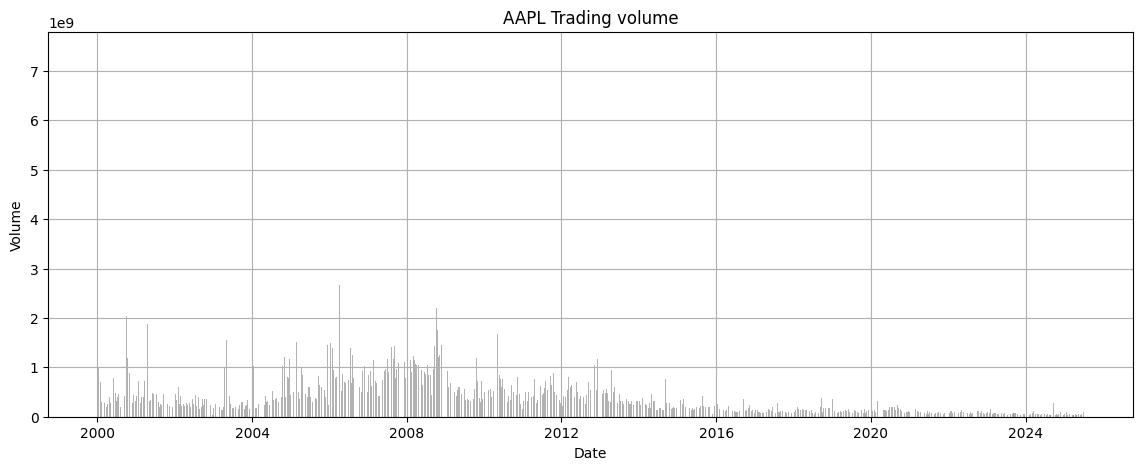

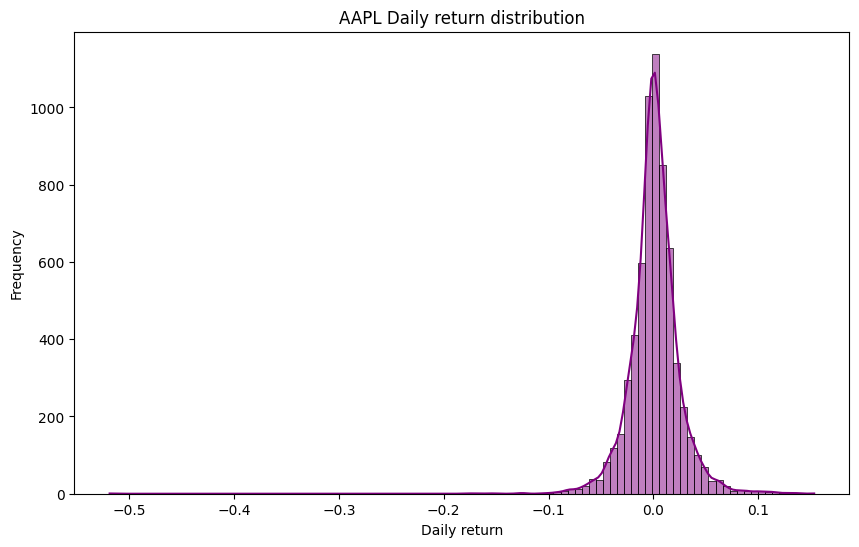


Correlation matrix:
            Open      High       Low     Close    Volume
Open    1.000000  0.999921  0.999925  0.999837 -0.473403
High    0.999921  1.000000  0.999895  0.999927 -0.473012
Low     0.999925  0.999895  1.000000  0.999923 -0.473918
Close   0.999837  0.999927  0.999923  1.000000 -0.473449
Volume -0.473403 -0.473012 -0.473918 -0.473449  1.000000


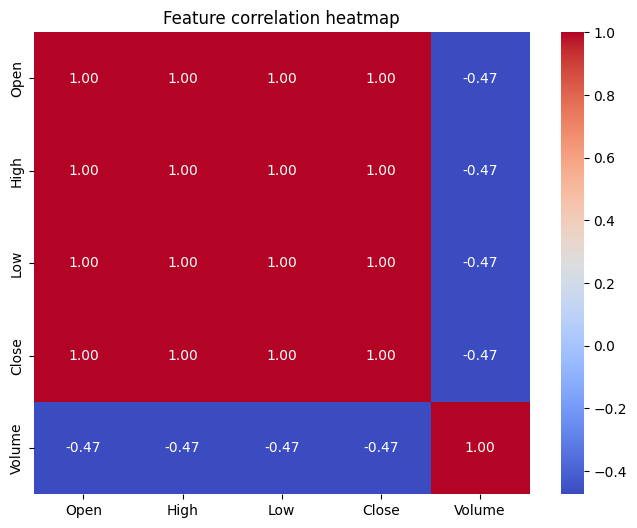

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_stock_data(df, ticker='AAPL'):
    """
    Performs exploratory data analysis on a specific stock ticker.
    """
    print(f"\nstock analysis for apple stocks {ticker} ---")

    if 'Ticker' in df.columns:
        df_ticker = df[df['Ticker'] == ticker].copy()
    elif 'Brand_Name' in df.columns:
        df_ticker = df[df['Brand_Name'].str.lower() == 'apple'].copy()
    else:
        print("no data found")

    # Convert Date to Datetime and Sort
    df_ticker['Date'] = pd.to_datetime(df_ticker['Date'])
    df_ticker = df_ticker.sort_values('Date')
    df_ticker.set_index('Date', inplace=True)

    # Check for missing values, applying data preprocessing from class
    print("Check missing values:")
    print(df_ticker.isnull().sum())

    # Price trend visualization
    plt.figure(figsize=(14, 7))
    plt.plot(df_ticker['Close'], label='Closing price', color='navy')
    plt.title(f'{ticker} Historical closing prices')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Volume analysis
    plt.figure(figsize=(14, 5))
    plt.bar(df_ticker.index, df_ticker['Volume'], color='gray', alpha=0.6)
    plt.title(f'{ticker} Trading volume')
    plt.xlabel('Date')
    plt.ylabel('Volume')
    plt.grid(True)
    plt.show()

    # Distribution of daily Returns showing the volatility of stocks
    # Calculate daily percentage change
    if 'Close' in df_ticker.columns:
        daily_returns = df_ticker['Close'].pct_change()
        plt.figure(figsize=(10, 6))
        sns.histplot(daily_returns.dropna(), bins=100, kde=True, color='purple')
        plt.title(f'{ticker} Daily return distribution')
        plt.xlabel('Daily return')
        plt.ylabel('Frequency')
        plt.show()
    else:
        print("no daily return distribution data")

    # Correlation Matrix of Features
    # We correlate Open, high, low, closing and Volume
    cols_for_corr = ['Open', 'High', 'Low', 'Close', 'Volume']
    if all(col in df_ticker.columns for col in cols_for_corr):
        corr_matrix = df_ticker[cols_for_corr].corr()
        print("\nCorrelation matrix:")
        print(corr_matrix)

        plt.figure(figsize=(8, 6))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
        plt.title('Feature correlation heatmap')
        plt.show()
    else:
        print("could not find columns")

    return df_ticker

if __name__ == "__main__":
    if 'stock_df' in locals() and stock_df is not None:
        apple_df = analyze_stock_data(stock_df, ticker='AAPL')
    else:
        print("no stock data")

# **Building the Linear Regression model using modified features from the data set. Lag features represent closing prices from the previous days while another feature called the Simple Moving average was computed for the previous week and previous month**

supervised learning model for AAPL
Generating Features for analysis
Feature set created. Total samples: 6450
Training on 5160 days (First 80%)
Testing on 1290 days (Last 20%)
Data scaling step


/tmp/ipykernel_464/277169051.py:24: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  data['Date'] = pd.to_datetime(data['Date'])


using a Linear regression model
Model Trained.
Intercept: 0.1910
Coefficients:
  Lag_1: 91.4469
  Lag_2: 17.3579
  SMA_5: 1.4843
  SMA_20: -3.7789
  Daily_Range: 0.5494

 Model performance
RMSE (root mean squared error): 3.0674
MAE (mean absolute error):      2.1506
R^2 Score:                      0.9932


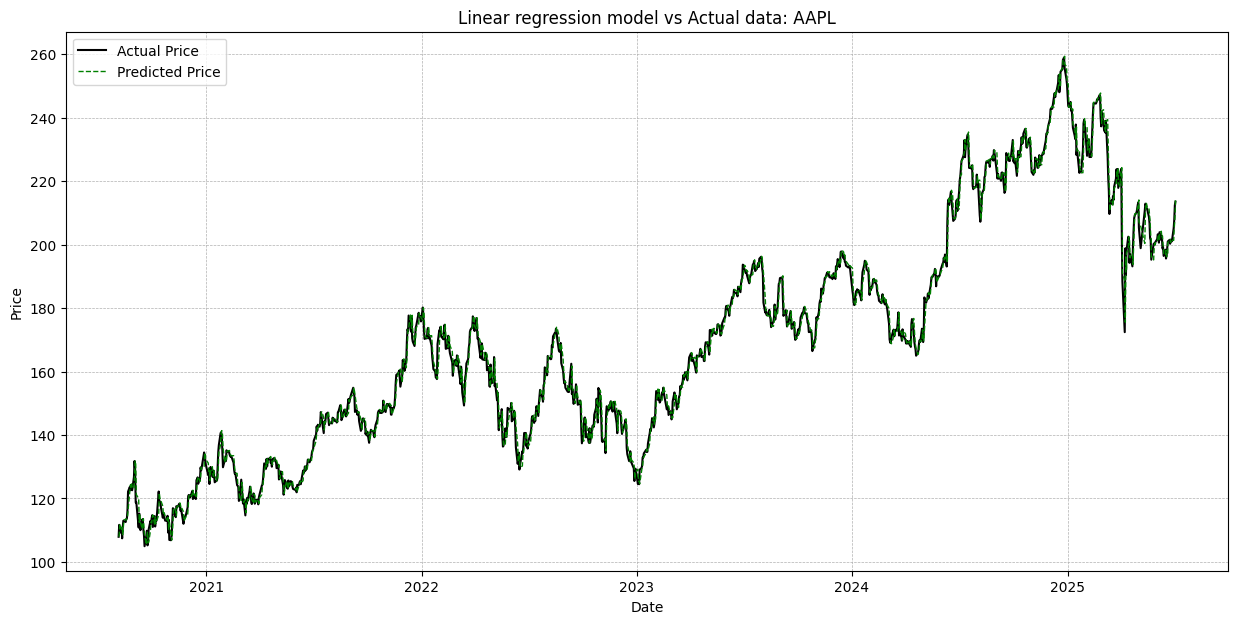

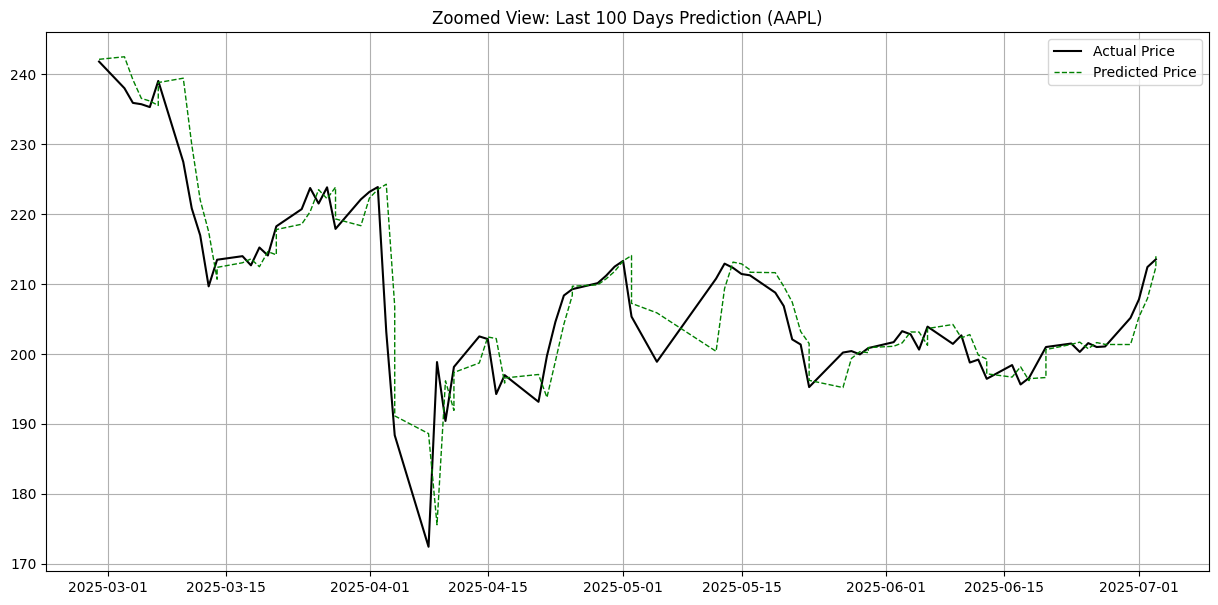

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

target_ticker = 'AAPL'
print(f"supervised learning model for {target_ticker}")

# Using 'Ticker' column to filter
if 'Ticker' in stock_df.columns:
    data = stock_df[stock_df['Ticker'] == target_ticker].copy()
elif 'Brand_Name' in stock_df.columns:
    data = stock_df[stock_df['Brand_Name'] == 'Apple'].copy()
else:
    print(f"no apple data")


if data.empty:
    raise ValueError(f"No data found for ticker '{target_ticker}'")


data['Date'] = pd.to_datetime(data['Date'])
data.sort_values('Date', inplace=True)
data.set_index('Date', inplace=True)

data = data[['Open', 'High', 'Low', 'Close', 'Volume']]

#Performing feature engineering
print("Generating Features for analysis")

# Lag Features using past data for prediction
data['Lag_1'] = data['Close'].shift(1)
data['Lag_2'] = data['Close'].shift(2)

# using rolling Window feature/Trends, i.e using the rolling mean on the shifted data to avoid data contamination by calculating the average of the past 5 days
data['SMA_5'] = data['Close'].shift(1).rolling(window=5).mean()
data['SMA_20'] = data['Close'].shift(1).rolling(window=20).mean()

# volatility
data['Daily_Range'] = data['High'].shift(1) - data['Low'].shift(1)

# Dropping NaN values created by shifting/rolling
data.dropna(inplace=True)

print(f"Feature set created. Total samples: {len(data)}")

# Supervised learning problem definition
# Target (y): current/today's close price
# Features (X): Lag_1, Lag_2, SMA_5, SMA_20, Daily_Range
feature_cols = ['Lag_1', 'Lag_2', 'SMA_5', 'SMA_20', 'Daily_Range']
X = data[feature_cols]
y = data['Close']

# Data split
split_ratio = 0.8
split_index = int(len(data) * split_ratio)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Training on {len(X_train)} days (First 80%)")
print(f"Testing on {len(X_test)} days (Last 20%)")

# Scaling the data as shown in class
print("Data scaling step")
scaler = MinMaxScaler(feature_range=(0, 1))

# using ttraining data
scaler.fit(X_train)


X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# The model
print("using a Linear regression model")
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Model Trained.")
print(f"Intercept: {model.intercept_:.4f}")
print("Coefficients:")
for feature, coef in zip(feature_cols, model.coef_):
    print(f"  {feature}: {coef:.4f}")

# Model testing and evaluating the model
predictions = model.predict(X_test_scaled)

# calculate the model accuracy
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("\n Model performance")
print(f"RMSE (root mean squared error): {rmse:.4f}")
print(f"MAE (mean absolute error):      {mae:.4f}")
print(f"R^2 Score:                      {r2:.4f}")

# Model plots
results = pd.DataFrame({'Actual': y_test, 'Predicted': predictions}, index=y_test.index)

plt.figure(figsize=(15, 7))
plt.plot(results['Actual'], label='Actual Price', color='black', linewidth=1.5)
plt.plot(results['Predicted'], label='Predicted Price', color='green', linestyle='--', linewidth=1)
plt.title(f'Linear regression model vs Actual data: {target_ticker}')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

# 100 days view
plt.figure(figsize=(15, 7))
plt.plot(results['Actual'].tail(100), label='Actual Price', color='black', linewidth=1.5)
plt.plot(results['Predicted'].tail(100), label='Predicted Price', color='green', linestyle='--', linewidth=1)
plt.title(f'Zoomed View: Last 100 Days Prediction ({target_ticker})')
plt.legend()
plt.grid(True)
plt.show()

## **Test the model on Google's data**

Using Colab cache for faster access to the 'world-stock-prices-daily-updating' dataset.
Dataset successfully downloaded/cached at: /kaggle/input/world-stock-prices-daily-updating
Identified primary data file: World-Stock-Prices-Dataset.csv
Loading the stocks data...
Shape of the stocks data: (310122, 13)

--- Stock analysis for AAPL ---


/tmp/ipykernel_230/1807549048.py:59: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_ticker['Date'] = pd.to_datetime(df_ticker['Date'])


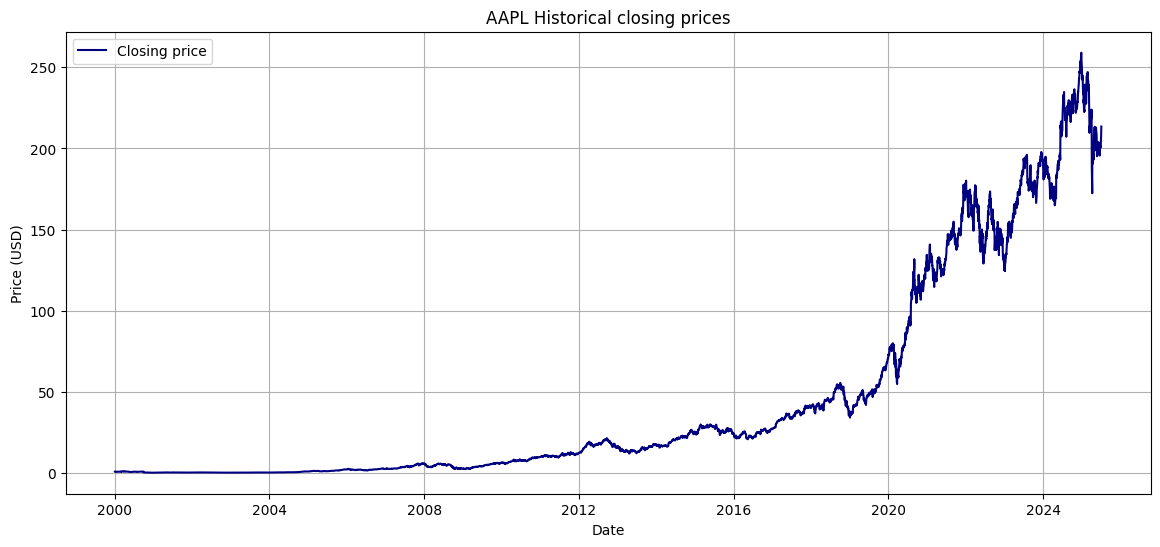


Generating Features for AAPL analysis...


/tmp/ipykernel_230/1807549048.py:90: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  data['Date'] = pd.to_datetime(data['Date'])



Training Linear Regression on AAPL...


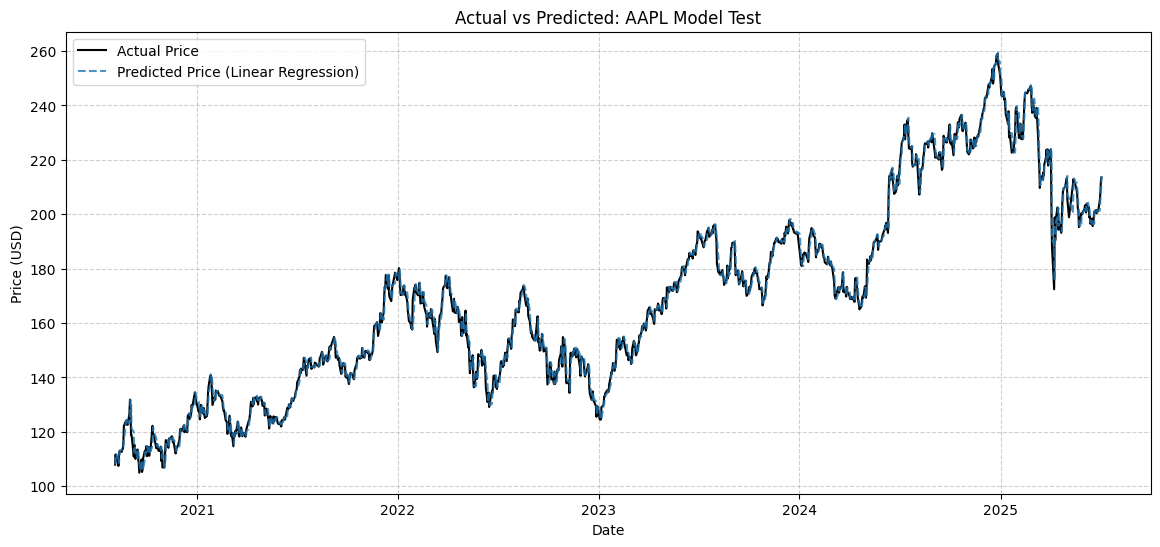

Training Random Forest on AAPL...


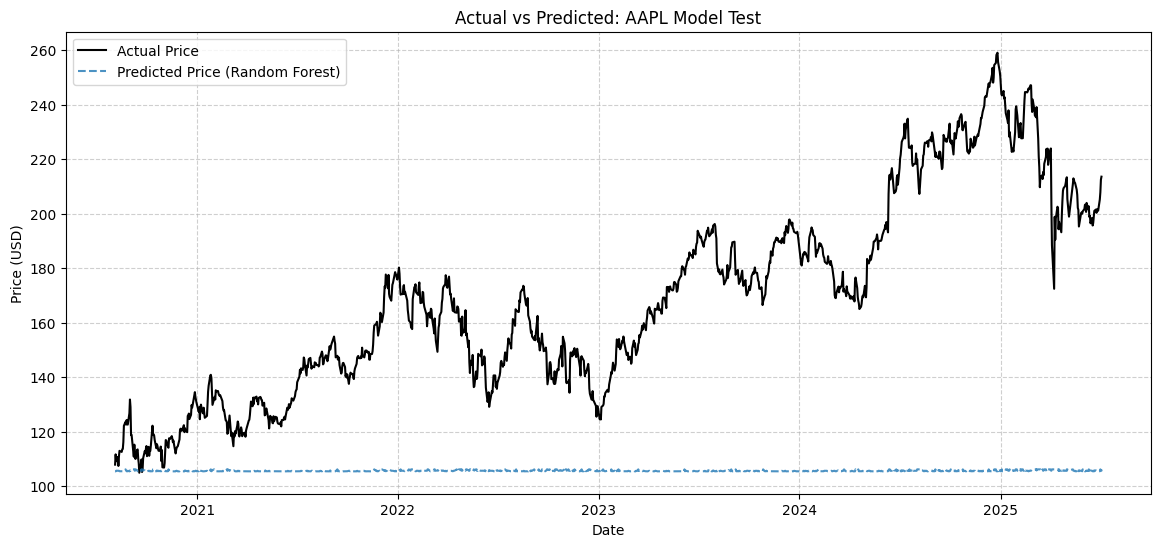

Training XGBoost on AAPL...


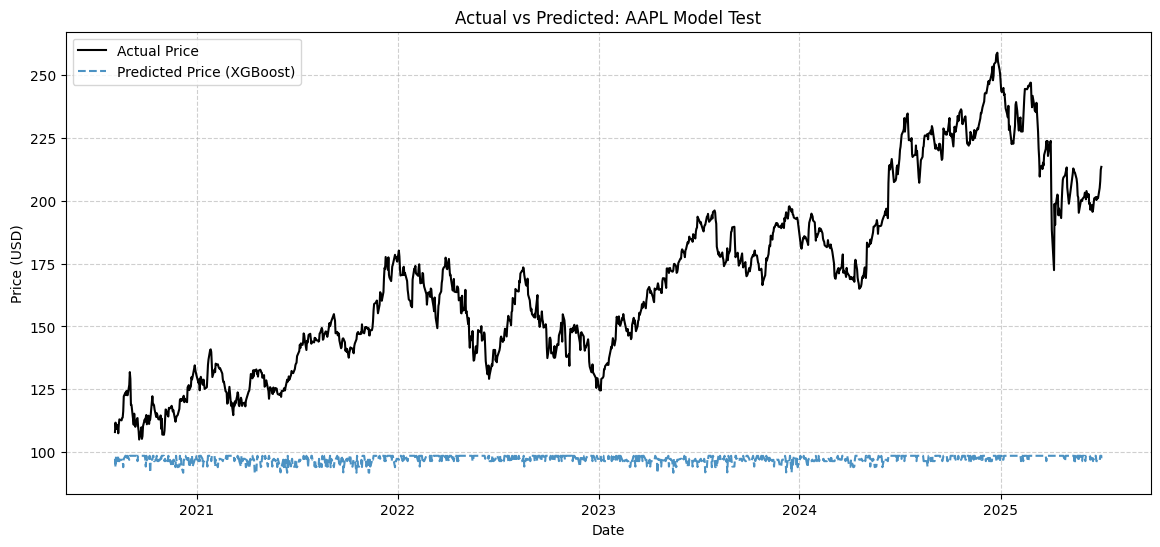


Fetching and processing GOOGL data...

--- Stock analysis for GOOGL ---


/tmp/ipykernel_230/1807549048.py:59: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_ticker['Date'] = pd.to_datetime(df_ticker['Date'])


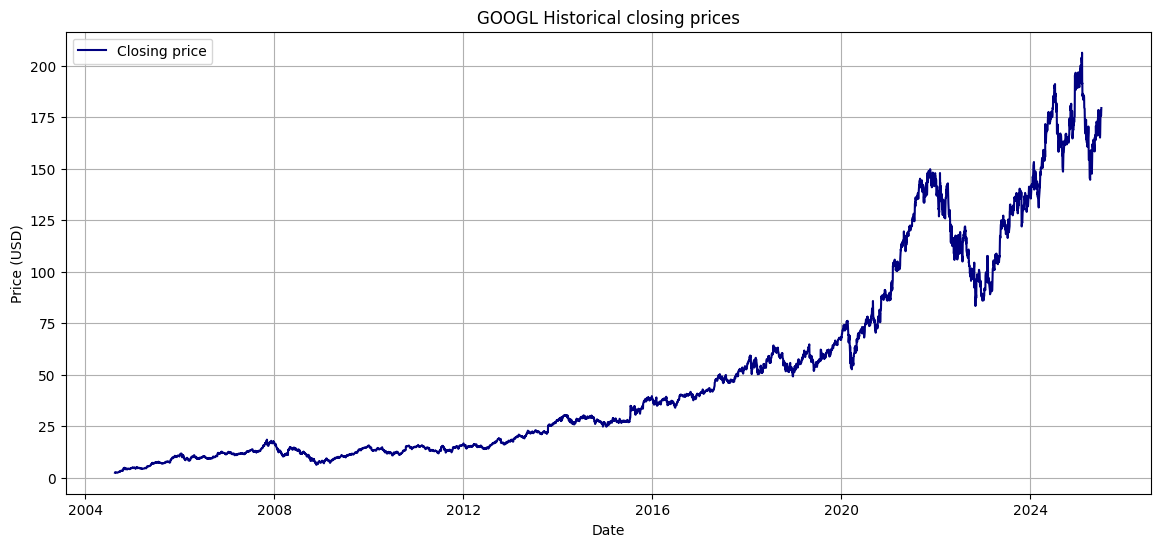

/tmp/ipykernel_230/1807549048.py:90: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  data['Date'] = pd.to_datetime(data['Date'])


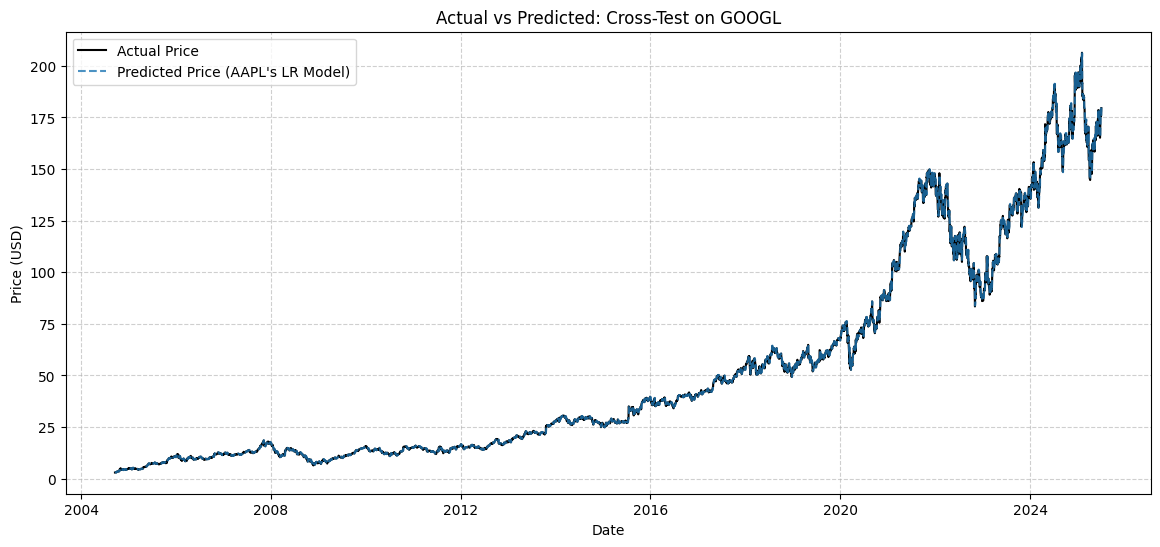


MODEL COMPARISON SUMMARY
                          Model      RMSE       MAE        R2
       AAPL - Linear Regression  3.067408  2.150608  0.993167
           AAPL - Random Forest 75.195980 65.428599 -3.106181
                 AAPL - XGBoost 82.534884 73.852028 -3.946795
GOOGL tested with AAPL LR Model  1.344017  0.679389  0.999299


In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# ==========================================
# 1. Data Extraction
# ==========================================
def fetch_stock_data():
    """Downloads the 'World Stock Prices' dataset and loads it."""
    dataset_handle = "nelgiriyewithana/world-stock-prices-daily-updating"
    print(f"Downloading the dataset: {dataset_handle}")

    try:
        path = kagglehub.dataset_download(dataset_handle)
        print(f"Dataset successfully downloaded/cached at: {path}")

        search_pattern = os.path.join(path, "**", "*.csv")
        csv_files = glob.glob(search_pattern, recursive=True)

        if not csv_files:
            raise FileNotFoundError("No CSV files found in the downloaded dataset directory.")

        primary_file = max(csv_files, key=os.path.getsize)
        print(f"Identified primary data file: {os.path.basename(primary_file)}")

        print("Loading the stocks data...")
        df = pd.read_csv(primary_file)
        print(f"Shape of the stocks data: {df.shape}")
        return df

    except Exception as e:
        print(f"CRITICAL ERROR during data extraction: {e}")
        return None

# ==========================================
# 2. Exploratory Data Analysis
# ==========================================
def analyze_stock_data(df, ticker='AAPL', brand_name='apple'):
    """Performs exploratory data analysis on a specific stock ticker."""
    print(f"\n--- Stock analysis for {ticker} ---")

    if 'Ticker' in df.columns:
        df_ticker = df[df['Ticker'] == ticker].copy()
    elif 'Brand_Name' in df.columns:
        df_ticker = df[df['Brand_Name'].str.lower() == brand_name].copy()
    else:
        print("No data found")
        return None

    df_ticker['Date'] = pd.to_datetime(df_ticker['Date'])
    df_ticker = df_ticker.sort_values('Date')
    df_ticker.set_index('Date', inplace=True)

    # Price trend visualization
    plt.figure(figsize=(14, 6))
    plt.plot(df_ticker['Close'], label='Closing price', color='navy')
    plt.title(f'{ticker} Historical closing prices')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.grid(True)
    plt.show()

    return df_ticker

# ==========================================
# 3. Feature Engineering Helper
# ==========================================
def prepare_features(df, ticker, brand_name):
    """Filters data for a ticker and generates predictive features."""
    if 'Ticker' in df.columns:
        data = df[df['Ticker'] == ticker].copy()
    elif 'Brand_Name' in df.columns:
        data = df[df['Brand_Name'].str.lower() == brand_name].copy()
    else:
        raise ValueError("Missing Ticker or Brand_Name column")

    if data.empty:
        raise ValueError(f"No data found for {ticker}")

    data['Date'] = pd.to_datetime(data['Date'])
    data.sort_values('Date', inplace=True)
    data.set_index('Date', inplace=True)
    data = data[['Open', 'High', 'Low', 'Close', 'Volume']]

    # Lag Features
    data['Lag_1'] = data['Close'].shift(1)
    data['Lag_2'] = data['Close'].shift(2)

    # Rolling Window Features (SMA)
    data['SMA_5'] = data['Close'].shift(1).rolling(window=5).mean()
    data['SMA_20'] = data['Close'].shift(1).rolling(window=20).mean()

    # Volatility Feature
    data['Daily_Range'] = data['High'].shift(1) - data['Low'].shift(1)

    # Drop NaNs created by shifting
    data.dropna(inplace=True)
    return data

# ==========================================
# 4. Evaluation & Plotting Helpers
# ==========================================
def evaluate_model(y_true, y_pred, model_name):
    """Calculates and returns evaluation metrics."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

def plot_actual_vs_predicted(dates, y_true, y_pred, model_name, title_suffix):
    """Generates a consistent plot for Actual vs Predicted values."""
    plt.figure(figsize=(14, 6))
    plt.plot(dates, y_true, label='Actual Price', color='black', linewidth=1.5)
    plt.plot(dates, y_pred, label=f'Predicted Price ({model_name})', linestyle='--', linewidth=1.5, alpha=0.8)
    plt.title(f'Actual vs Predicted: {title_suffix}')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# ==========================================
# MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    # 1. Fetch Data
    stock_df = fetch_stock_data()

    if stock_df is not None:
        # 2. EDA for Apple
        apple_raw_data = analyze_stock_data(stock_df, ticker='AAPL', brand_name='apple')

        # 3. Prepare Apple Data for ML
        print("\nGenerating Features for AAPL analysis...")
        aapl_data = prepare_features(stock_df, ticker='AAPL', brand_name='apple')

        feature_cols = ['Lag_1', 'Lag_2', 'SMA_5', 'SMA_20', 'Daily_Range']
        X = aapl_data[feature_cols]
        y = aapl_data['Close']

        # Data split (80/20)
        split_index = int(len(aapl_data) * 0.8)
        X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
        y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

        # Scaling
        scaler = MinMaxScaler(feature_range=(0, 1))
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        results_list = []

        # ---------------------------------------------------------
        # 4. Train & Plot Models on AAPL
        # ---------------------------------------------------------
        # A. Linear Regression
        print("\nTraining Linear Regression on AAPL...")
        lr_model = LinearRegression()
        lr_model.fit(X_train_scaled, y_train)
        lr_preds = lr_model.predict(X_test_scaled)
        results_list.append(evaluate_model(y_test, lr_preds, "AAPL - Linear Regression"))
        plot_actual_vs_predicted(y_test.index, y_test, lr_preds, "Linear Regression", "AAPL Model Test")

        # B. Random Forest
        print("Training Random Forest on AAPL...")
        rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
        rf_model.fit(X_train_scaled, y_train)
        rf_preds = rf_model.predict(X_test_scaled)
        results_list.append(evaluate_model(y_test, rf_preds, "AAPL - Random Forest"))
        plot_actual_vs_predicted(y_test.index, y_test, rf_preds, "Random Forest", "AAPL Model Test")

        # C. XGBoost
        print("Training XGBoost on AAPL...")
        xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
        xgb_model.fit(X_train_scaled, y_train)
        xgb_preds = xgb_model.predict(X_test_scaled)
        results_list.append(evaluate_model(y_test, xgb_preds, "AAPL - XGBoost"))
        plot_actual_vs_predicted(y_test.index, y_test, xgb_preds, "XGBoost", "AAPL Model Test")

        # ---------------------------------------------------------
        # 5. Cross-Test: Predict Google (GOOGL) using AAPL's LR Model
        # ---------------------------------------------------------
        print("\nFetching and processing GOOGL data...")
        google_raw_data = analyze_stock_data(stock_df, ticker='GOOGL', brand_name='google')
        googl_data = prepare_features(stock_df, ticker='GOOGL', brand_name='google')

        X_googl = googl_data[feature_cols]
        y_googl = googl_data['Close']

        # Transform Google's data using the AAPL-fitted scaler
        X_googl_scaled = scaler.transform(X_googl)

        # Predict Google using the Apple-trained models (We'll use LR for the plot as requested)
        googl_preds_using_aapl_lr = lr_model.predict(X_googl_scaled)
        results_list.append(evaluate_model(y_googl, googl_preds_using_aapl_lr, "GOOGL tested with AAPL LR Model"))

        # Plot the Cross-Test
        plot_actual_vs_predicted(y_googl.index, y_googl, googl_preds_using_aapl_lr, "AAPL's LR Model", "Cross-Test on GOOGL")

        # ---------------------------------------------------------
        # 6. Comparisons and Visualizations
        # ---------------------------------------------------------
        print("\n" + "="*65)
        print("MODEL COMPARISON SUMMARY")
        print("="*65)
        results_df = pd.DataFrame(results_list)
        print(results_df.to_string(index=False))
        print("="*65)

## **INVESTIGATING AND FIXING WHY THE TREE-ALGORITHMS PERFORMED POORLY** MOVING AHEAD TO TEST THE LINEAR REGRESSION MODEL ON GOOGLE'S DATA AND TESLA'S DATA

THE MODEL PERFORMED WELL IN BOTH CASES


Using Colab cache for faster access to the 'world-stock-prices-daily-updating' dataset.
Loading the stocks data...

Generating Features for AAPL analysis...


/tmp/ipykernel_464/90013172.py:52: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  data['Date'] = pd.to_datetime(data['Date'])



Training Linear Regression on AAPL...


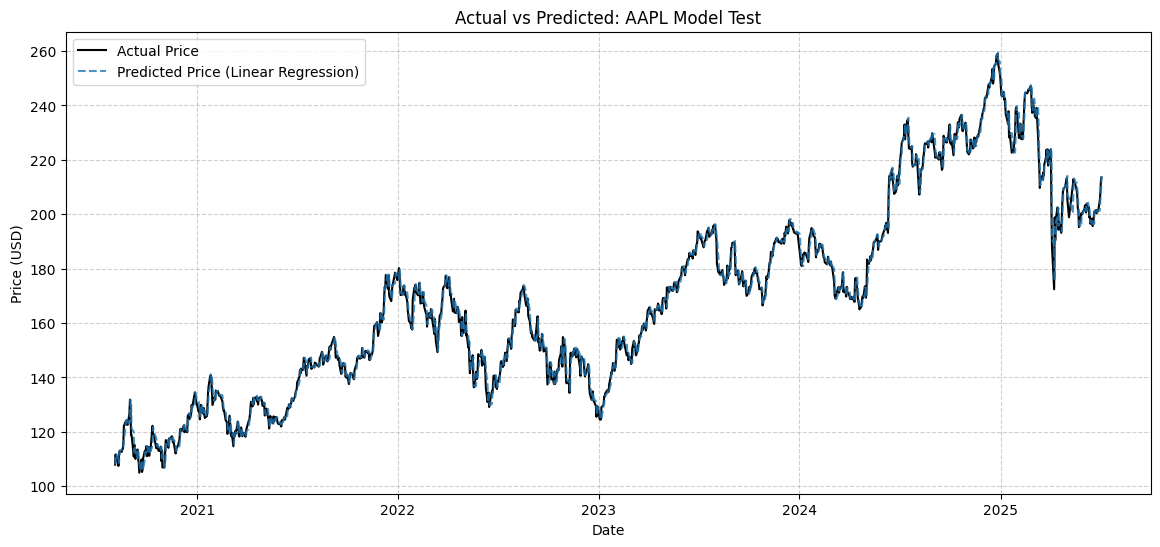

Training Random Forest on AAPL...


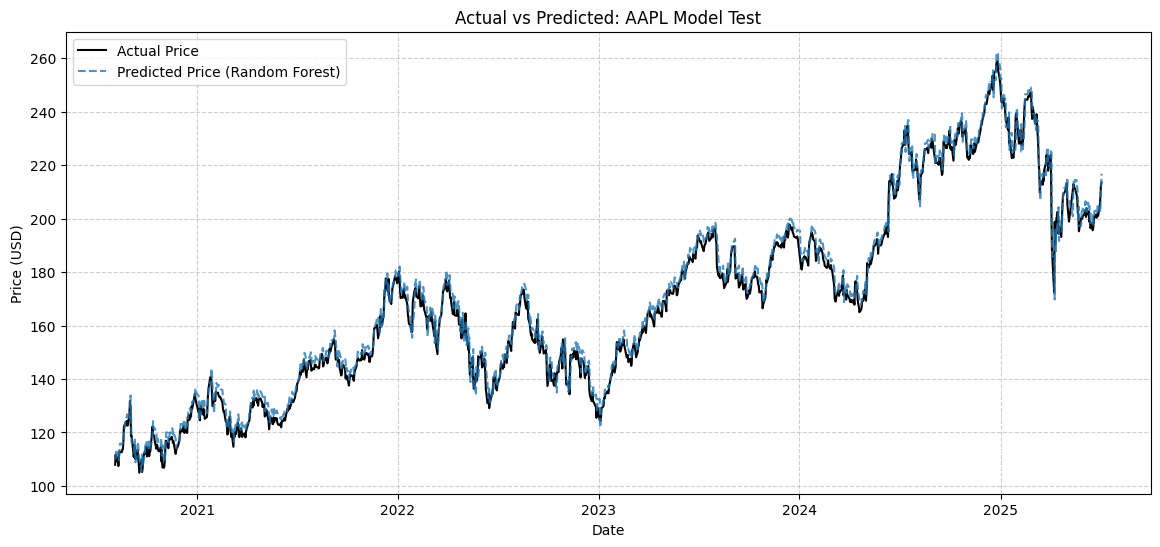

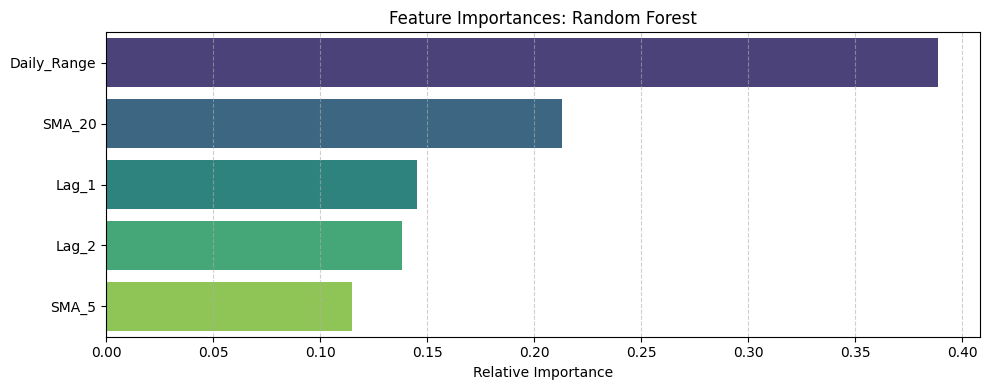

Training XGBoost on AAPL...


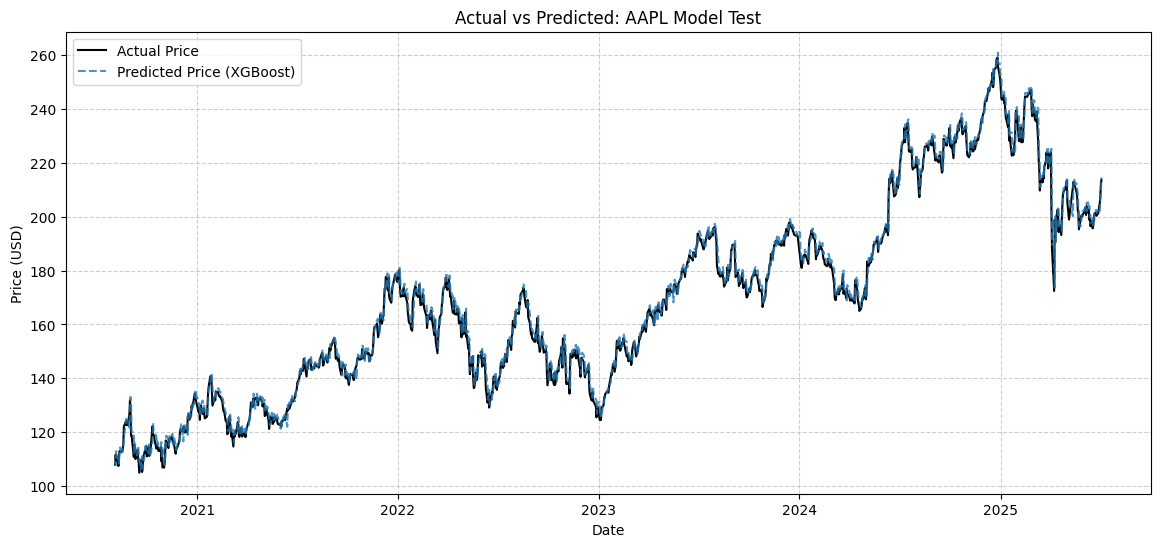

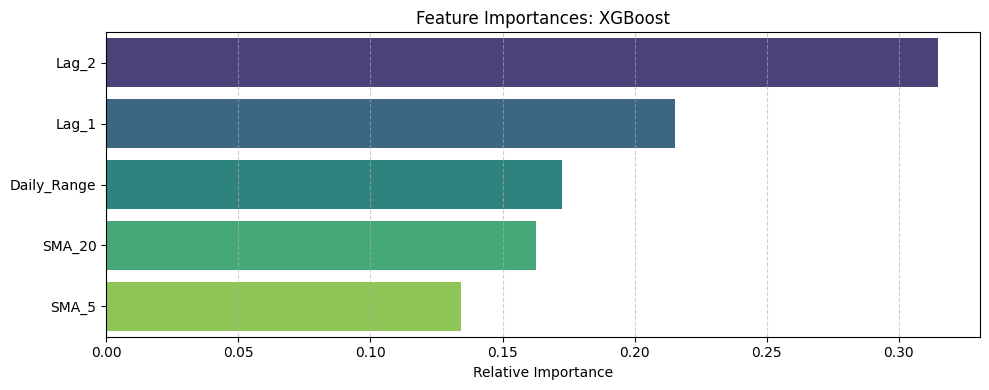


Fetching and processing GOOGL data...


/tmp/ipykernel_464/90013172.py:52: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  data['Date'] = pd.to_datetime(data['Date'])


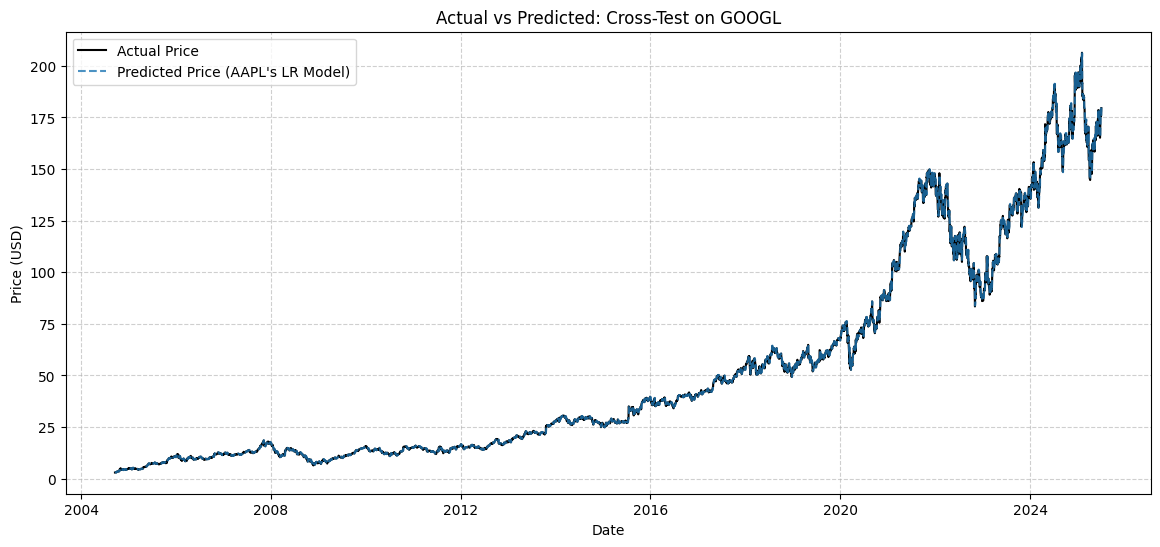


MODEL COMPARISON SUMMARY
                          Model     RMSE      MAE       R2
       AAPL - Linear Regression 3.067408 2.150608 0.993167
           AAPL - Random Forest 3.849926 3.043486 0.989236
                 AAPL - XGBoost 3.279098 2.384490 0.992192
GOOGL tested with AAPL LR Model 1.344017 0.679389 0.999299


In [6]:
import kagglehub
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# ==========================================
# 1. Data Extraction
# ==========================================
def fetch_stock_data():
    """Downloads the 'World Stock Prices' dataset and loads it."""
    dataset_handle = "nelgiriyewithana/world-stock-prices-daily-updating"
    print(f"Downloading the dataset: {dataset_handle}")

    try:
        path = kagglehub.dataset_download(dataset_handle)

        search_pattern = os.path.join(path, "**", "*.csv")
        csv_files = glob.glob(search_pattern, recursive=True)

        if not csv_files:
            raise FileNotFoundError("No CSV files found in the downloaded dataset directory.")

        primary_file = max(csv_files, key=os.path.getsize)
        print(f"Loading the stocks data...")
        df = pd.read_csv(primary_file)
        return df

    except Exception as e:
        print(f"CRITICAL ERROR during data extraction: {e}")
        return None

# ==========================================
# 2. Feature Engineering Helper
# ==========================================
def prepare_features(df, ticker, brand_name):
    """Filters data for a ticker and generates predictive features."""
    if 'Ticker' in df.columns:
        data = df[df['Ticker'] == ticker].copy()
    elif 'Brand_Name' in df.columns:
        data = df[df['Brand_Name'].str.lower() == brand_name].copy()
    else:
        raise ValueError("Missing Ticker or Brand_Name column")

    data['Date'] = pd.to_datetime(data['Date'])
    data.sort_values('Date', inplace=True)
    data.set_index('Date', inplace=True)
    data = data[['Open', 'High', 'Low', 'Close', 'Volume']]

    # Lag Features
    data['Lag_1'] = data['Close'].shift(1)
    data['Lag_2'] = data['Close'].shift(2)

    # Rolling Window Features (SMA)
    data['SMA_5'] = data['Close'].shift(1).rolling(window=5).mean()
    data['SMA_20'] = data['Close'].shift(1).rolling(window=20).mean()

    # Volatility Feature
    data['Daily_Range'] = data['High'].shift(1) - data['Low'].shift(1)

    # THE FIX: Create a stationary target variable (Daily Change)
    data['Price_Change'] = data['Close'] - data['Lag_1']

    # Drop NaNs created by shifting
    data.dropna(inplace=True)
    return data

# ==========================================
# 3. Evaluation & Plotting Helpers
# ==========================================
def evaluate_model(y_true, y_pred, model_name):
    """Calculates and returns evaluation metrics."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

def plot_actual_vs_predicted(dates, y_true, y_pred, model_name, title_suffix):
    """Generates a consistent plot for Actual vs Predicted values."""
    plt.figure(figsize=(14, 6))
    plt.plot(dates, y_true, label='Actual Price', color='black', linewidth=1.5)
    plt.plot(dates, y_pred, label=f'Predicted Price ({model_name})', linestyle='--', linewidth=1.5, alpha=0.8)
    plt.title(f'Actual vs Predicted: {title_suffix}')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

def plot_feature_importance(model, feature_names, model_name):
    """Extracts and plots feature importances for tree-based models."""
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    sorted_features = [feature_names[i] for i in indices]
    sorted_importances = importances[indices]

    plt.figure(figsize=(10, 4))
    sns.barplot(x=sorted_importances, y=sorted_features, hue=sorted_features, palette='viridis', legend=False)
    plt.title(f'Feature Importances: {model_name}')
    plt.xlabel('Relative Importance')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# ==========================================
# MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    stock_df = fetch_stock_data()

    if stock_df is not None:
        print("\nGenerating Features for AAPL analysis...")
        aapl_data = prepare_features(stock_df, ticker='AAPL', brand_name='apple')

        feature_cols = ['Lag_1', 'Lag_2', 'SMA_5', 'SMA_20', 'Daily_Range']
        X = aapl_data[feature_cols]

        # We extract both the change (for training) and the absolute close (for evaluation)
        y_change = aapl_data['Price_Change']
        y_actual_close = aapl_data['Close']

        # Data split (80/20)
        split_index = int(len(aapl_data) * 0.8)
        X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]

        # Train on the CHANGE, not the absolute price
        y_train_change = y_change.iloc[:split_index]

        # Keep the actual test closing prices for evaluation plotting later
        y_test_close = y_actual_close.iloc[split_index:]

        # Scaling
        scaler = MinMaxScaler(feature_range=(0, 1))
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        results_list = []

        # ---------------------------------------------------------
        # A. Linear Regression
        # ---------------------------------------------------------
        print("\nTraining Linear Regression on AAPL...")
        lr_model = LinearRegression()
        lr_model.fit(X_train_scaled, y_train_change)

        # Predict the change, then add it to yesterday's price to get today's predicted price
        lr_preds_change = lr_model.predict(X_test_scaled)
        lr_preds_close = X_test['Lag_1'].values + lr_preds_change

        results_list.append(evaluate_model(y_test_close, lr_preds_close, "AAPL - Linear Regression"))
        plot_actual_vs_predicted(y_test_close.index, y_test_close, lr_preds_close, "Linear Regression", "AAPL Model Test")

        # ---------------------------------------------------------
        # B. Random Forest
        # ---------------------------------------------------------
        print("Training Random Forest on AAPL...")
        rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
        rf_model.fit(X_train_scaled, y_train_change)

        rf_preds_change = rf_model.predict(X_test_scaled)
        rf_preds_close = X_test['Lag_1'].values + rf_preds_change

        results_list.append(evaluate_model(y_test_close, rf_preds_close, "AAPL - Random Forest"))
        plot_actual_vs_predicted(y_test_close.index, y_test_close, rf_preds_close, "Random Forest", "AAPL Model Test")
        plot_feature_importance(rf_model, feature_cols, "Random Forest")

        # ---------------------------------------------------------
        # C. XGBoost
        # ---------------------------------------------------------
        print("Training XGBoost on AAPL...")
        xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
        xgb_model.fit(X_train_scaled, y_train_change)

        xgb_preds_change = xgb_model.predict(X_test_scaled)
        xgb_preds_close = X_test['Lag_1'].values + xgb_preds_change

        results_list.append(evaluate_model(y_test_close, xgb_preds_close, "AAPL - XGBoost"))
        plot_actual_vs_predicted(y_test_close.index, y_test_close, xgb_preds_close, "XGBoost", "AAPL Model Test")
        plot_feature_importance(xgb_model, feature_cols, "XGBoost")

        # ---------------------------------------------------------
        # Cross-Test: Predict Google (GOOGL) using AAPL's LR Model
        # ---------------------------------------------------------
        print("\nFetching and processing GOOGL data...")
        googl_data = prepare_features(stock_df, ticker='GOOGL', brand_name='google')

        X_googl = googl_data[feature_cols]
        y_googl_close = googl_data['Close']

        X_googl_scaled = scaler.transform(X_googl)

        # Predict Google using the Apple-trained model
        googl_preds_change = lr_model.predict(X_googl_scaled)
        googl_preds_close = X_googl['Lag_1'].values + googl_preds_change

        results_list.append(evaluate_model(y_googl_close, googl_preds_close, "GOOGL tested with AAPL LR Model"))
        plot_actual_vs_predicted(y_googl_close.index, y_googl_close, googl_preds_close, "AAPL's LR Model", "Cross-Test on GOOGL")

        # ---------------------------------------------------------
        # Summary
        # ---------------------------------------------------------
        print("\n" + "="*65)
        print("MODEL COMPARISON SUMMARY")
        print("="*65)
        results_df = pd.DataFrame(results_list)
        print(results_df.to_string(index=False))
        print("="*65)

Using Colab cache for faster access to the 'world-stock-prices-daily-updating' dataset.
Loading the stocks data...

--- 1. Generating Features for AAPL ---
Training Linear Regression on AAPL...


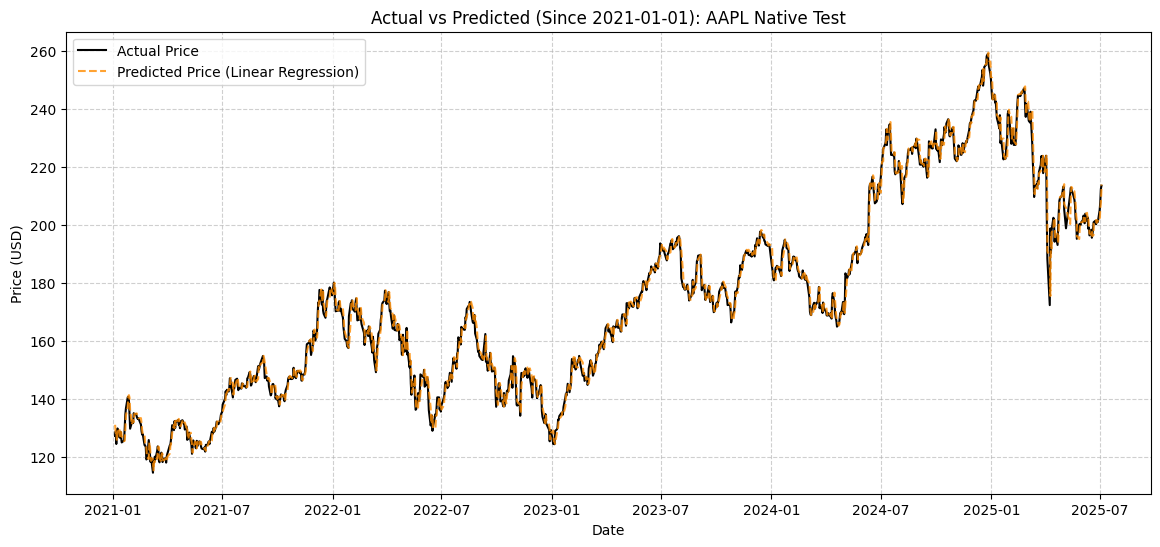

Training Random Forest on AAPL...


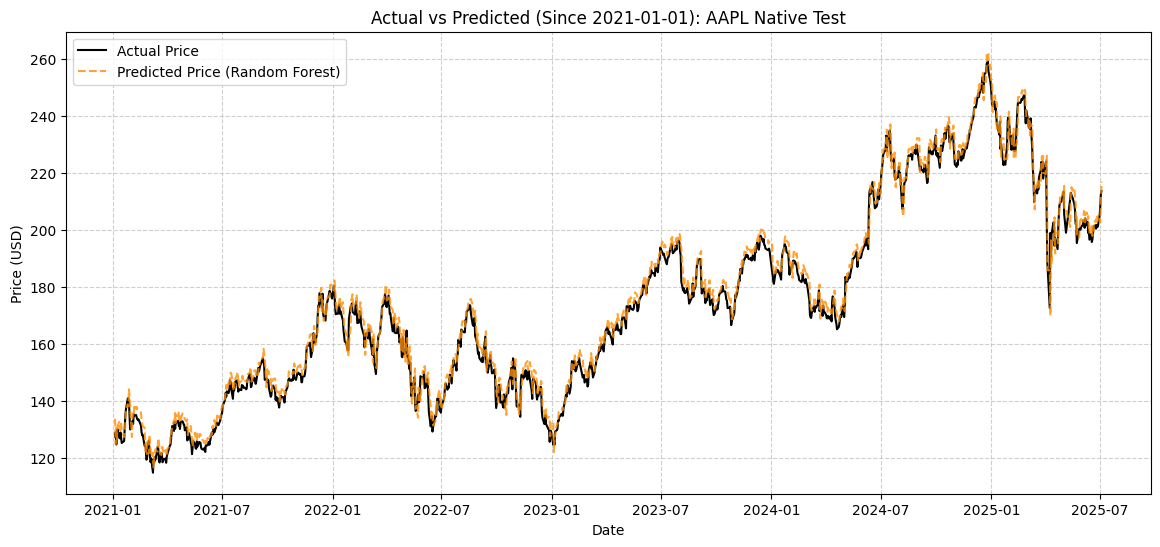

Training XGBoost on AAPL...


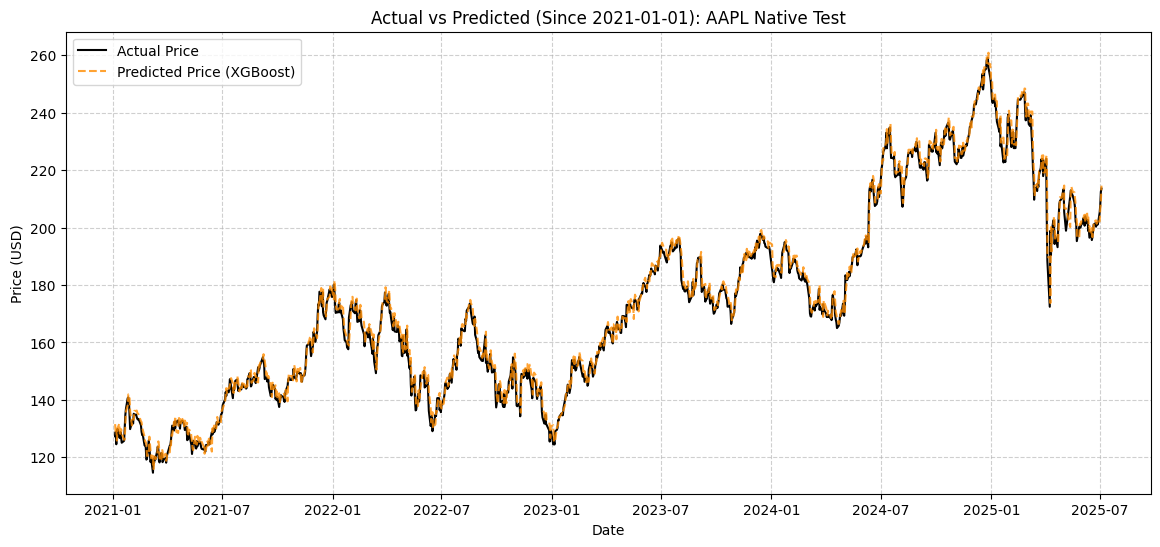


--- 2. Fetching and processing GOOGL data ---


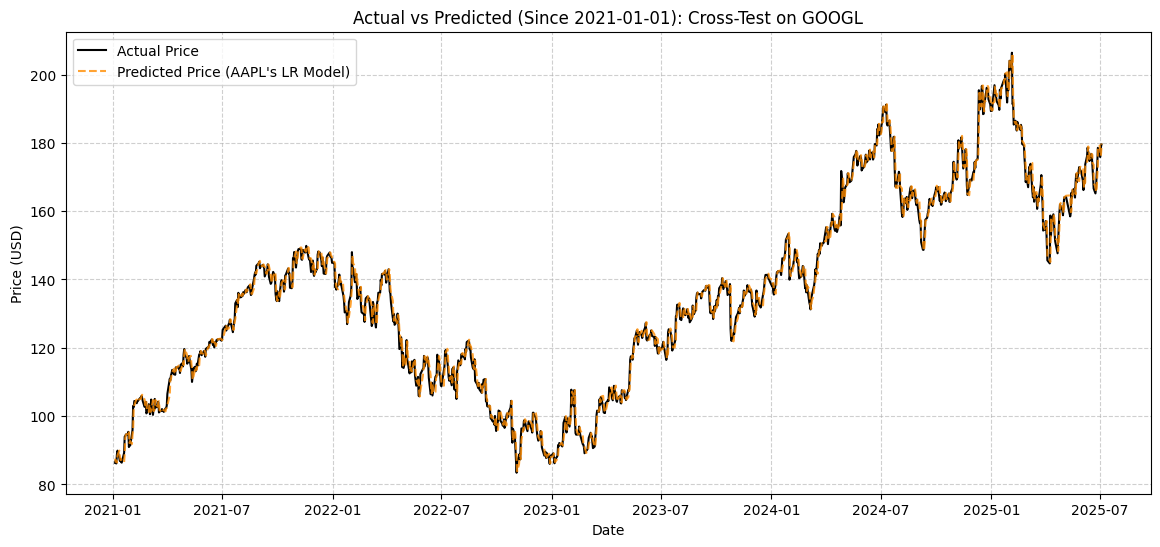


--- 3. Fetching and processing TSLA data ---


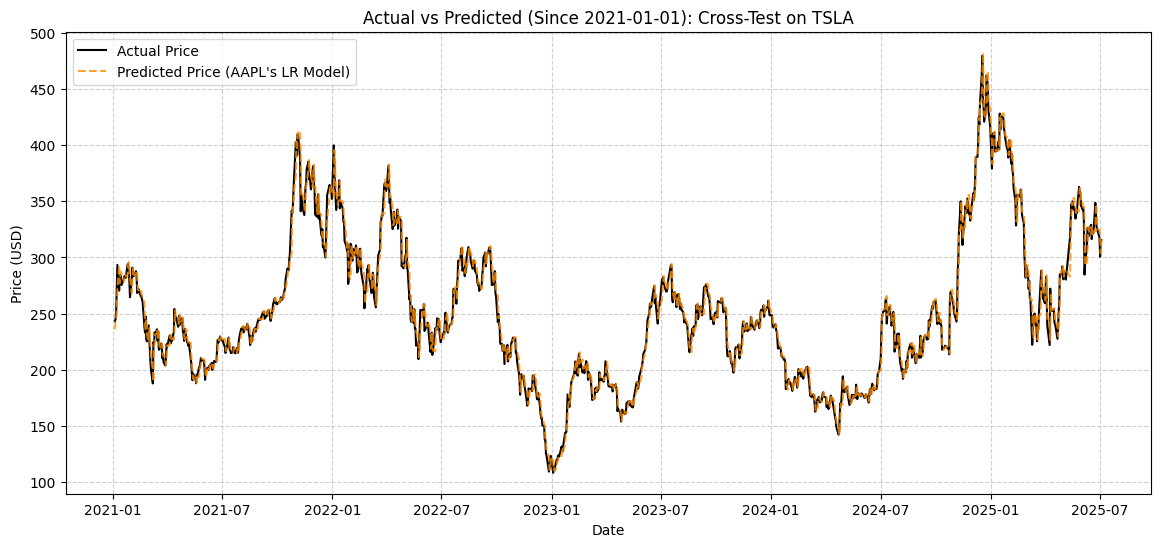


FINAL MODEL ACCURACY METRICS
Model                      RMSE   MAE    R2 Score
 AAPL - Linear Regression 3.0674 2.1506 0.9932   
     AAPL - Random Forest 3.8499 3.0435 0.9892   
           AAPL - XGBoost 3.2791 2.3845 0.9922   
GOOGL (Tested w/ AAPL LR) 1.3440 0.6794 0.9993   
 TSLA (Tested w/ AAPL LR) 5.7902 2.5805 0.9975   


In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# ==========================================
# 1. Data Extraction
# ==========================================
def fetch_stock_data():
    """Downloads the 'World Stock Prices' dataset and loads it."""
    dataset_handle = "nelgiriyewithana/world-stock-prices-daily-updating"
    print(f"Downloading the dataset: {dataset_handle}")

    try:
        path = kagglehub.dataset_download(dataset_handle)

        search_pattern = os.path.join(path, "**", "*.csv")
        csv_files = glob.glob(search_pattern, recursive=True)

        if not csv_files:
            raise FileNotFoundError("No CSV files found in the downloaded dataset directory.")

        primary_file = max(csv_files, key=os.path.getsize)
        print(f"Loading the stocks data...")
        df = pd.read_csv(primary_file)
        return df

    except Exception as e:
        print(f"CRITICAL ERROR during data extraction: {e}")
        return None

# ==========================================
# 2. Feature Engineering Helper
# ==========================================
def prepare_features(df, ticker, brand_name):
    """Filters data for a ticker and generates predictive features."""
    if 'Ticker' in df.columns:
        data = df[df['Ticker'] == ticker].copy()
    elif 'Brand_Name' in df.columns:
        data = df[df['Brand_Name'].str.lower() == brand_name.lower()].copy()
    else:
        raise ValueError("Missing Ticker or Brand_Name column")

    # Parse dates uniformly as UTC, then make them timezone-naive to avoid comparison issues later
    data['Date'] = pd.to_datetime(data['Date'], utc=True).dt.tz_localize(None)
    data.sort_values('Date', inplace=True)
    data.set_index('Date', inplace=True)
    data = data[['Open', 'High', 'Low', 'Close', 'Volume']]

    # Lag Features
    data['Lag_1'] = data['Close'].shift(1)
    data['Lag_2'] = data['Close'].shift(2)

    # Rolling Window Features (SMA)
    data['SMA_5'] = data['Close'].shift(1).rolling(window=5).mean()
    data['SMA_20'] = data['Close'].shift(1).rolling(window=20).mean()

    # Volatility Feature
    data['Daily_Range'] = data['High'].shift(1) - data['Low'].shift(1)

    # The Target: Predict the daily change to prevent Tree-model extrapolation limits
    data['Price_Change'] = data['Close'] - data['Lag_1']

    # Drop NaNs created by shifting
    data.dropna(inplace=True)
    return data

# ==========================================
# 3. Evaluation & Plotting Helpers
# ==========================================
def evaluate_model(y_true, y_pred, model_name):
    """Calculates and returns evaluation metrics."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'R2 Score': r2}

def plot_actual_vs_predicted(dates, y_true, y_pred, model_name, title_suffix, start_date='2021-01-01'):
    """Generates a consistent plot zoomed in from a specific start date."""
    # Combine into a temporary DataFrame to easily filter by date
    temp_df = pd.DataFrame({'Actual': y_true, 'Predicted': y_pred}, index=dates)

    # Apply the date zoom
    if start_date:
        # Since dates are now guaranteed to be timezone-naive, we can directly compare them
        temp_df = temp_df.loc[temp_df.index >= pd.to_datetime(start_date)]

    plt.figure(figsize=(14, 6))
    plt.plot(temp_df.index, temp_df['Actual'], label='Actual Price', color='black', linewidth=1.5)
    plt.plot(temp_df.index, temp_df['Predicted'], label=f'Predicted Price ({model_name})', color='darkorange', linestyle='--', linewidth=1.5, alpha=0.8)
    plt.title(f'Actual vs Predicted (Since {start_date}): {title_suffix}')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# ==========================================
# MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    stock_df = fetch_stock_data()

    if stock_df is not None:
        print("\n--- 1. Generating Features for AAPL ---")
        aapl_data = prepare_features(stock_df, ticker='AAPL', brand_name='apple')

        feature_cols = ['Lag_1', 'Lag_2', 'SMA_5', 'SMA_20', 'Daily_Range']
        X = aapl_data[feature_cols]
        y_change = aapl_data['Price_Change']
        y_actual_close = aapl_data['Close']

        # Data split (80/20)
        split_index = int(len(aapl_data) * 0.8)
        X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
        y_train_change = y_change.iloc[:split_index]
        y_test_close = y_actual_close.iloc[split_index:]

        # Scaling
        scaler = MinMaxScaler(feature_range=(0, 1))
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        results_list = []

        # ---------------------------------------------------------
        # A. Apple - Linear Regression
        # ---------------------------------------------------------
        print("Training Linear Regression on AAPL...")
        lr_model = LinearRegression()
        lr_model.fit(X_train_scaled, y_train_change)

        lr_preds_change = lr_model.predict(X_test_scaled)
        lr_preds_close = X_test['Lag_1'].values + lr_preds_change

        results_list.append(evaluate_model(y_test_close, lr_preds_close, "AAPL - Linear Regression"))
        plot_actual_vs_predicted(y_test_close.index, y_test_close, lr_preds_close, "Linear Regression", "AAPL Native Test")

        # ---------------------------------------------------------
        # B. Apple - Random Forest
        # ---------------------------------------------------------
        print("Training Random Forest on AAPL...")
        rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
        rf_model.fit(X_train_scaled, y_train_change)

        rf_preds_change = rf_model.predict(X_test_scaled)
        rf_preds_close = X_test['Lag_1'].values + rf_preds_change

        results_list.append(evaluate_model(y_test_close, rf_preds_close, "AAPL - Random Forest"))
        plot_actual_vs_predicted(y_test_close.index, y_test_close, rf_preds_close, "Random Forest", "AAPL Native Test")

        # ---------------------------------------------------------
        # C. Apple - XGBoost
        # ---------------------------------------------------------
        print("Training XGBoost on AAPL...")
        xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
        xgb_model.fit(X_train_scaled, y_train_change)

        xgb_preds_change = xgb_model.predict(X_test_scaled)
        xgb_preds_close = X_test['Lag_1'].values + xgb_preds_change

        results_list.append(evaluate_model(y_test_close, xgb_preds_close, "AAPL - XGBoost"))
        plot_actual_vs_predicted(y_test_close.index, y_test_close, xgb_preds_close, "XGBoost", "AAPL Native Test")

        # ---------------------------------------------------------
        # 2. Cross-Test: Predict Google (GOOGL) using AAPL's LR Model
        # ---------------------------------------------------------
        print("\n--- 2. Fetching and processing GOOGL data ---")
        googl_data = prepare_features(stock_df, ticker='GOOGL', brand_name='google')

        X_googl = googl_data[feature_cols]
        y_googl_close = googl_data['Close']

        # Transform Google's features using the Apple scaler
        X_googl_scaled = scaler.transform(X_googl)

        # Predict Google's price change using Apple's model
        googl_preds_change = lr_model.predict(X_googl_scaled)
        # Convert to absolute price
        googl_preds_close = X_googl['Lag_1'].values + googl_preds_change

        results_list.append(evaluate_model(y_googl_close, googl_preds_close, "GOOGL (Tested w/ AAPL LR)"))
        plot_actual_vs_predicted(y_googl_close.index, y_googl_close, googl_preds_close, "AAPL's LR Model", "Cross-Test on GOOGL")

        # ---------------------------------------------------------
        # 3. Cross-Test: Predict Tesla (TSLA) using AAPL's LR Model
        # ---------------------------------------------------------
        print("\n--- 3. Fetching and processing TSLA data ---")
        tsla_data = prepare_features(stock_df, ticker='TSLA', brand_name='tesla')

        X_tsla = tsla_data[feature_cols]
        y_tsla_close = tsla_data['Close']

        # Transform Tesla's features using the Apple scaler
        X_tsla_scaled = scaler.transform(X_tsla)

        # Predict Tesla's price change using Apple's model
        tsla_preds_change = lr_model.predict(X_tsla_scaled)
        # Convert to absolute price
        tsla_preds_close = X_tsla['Lag_1'].values + tsla_preds_change

        results_list.append(evaluate_model(y_tsla_close, tsla_preds_close, "TSLA (Tested w/ AAPL LR)"))
        plot_actual_vs_predicted(y_tsla_close.index, y_tsla_close, tsla_preds_close, "AAPL's LR Model", "Cross-Test on TSLA")

        # ---------------------------------------------------------
        # 4. Final Accuracy Metrics Table
        # ---------------------------------------------------------
        print("\n" + "="*70)
        print("FINAL MODEL ACCURACY METRICS")
        print("="*70)
        results_df = pd.DataFrame(results_list)

        # Formatting the DataFrame to look like a clean table
        pd.set_option('display.float_format', '{:.4f}'.format)
        print(results_df.to_string(index=False, justify='left'))
        print("="*70)